11/02/2026

In [2]:
import pandas as pd 
import matplotlib.pyplot as plt 
import numpy as np 

In [3]:
df=pd.read_csv("placement.csv")
print(df.head())

   cgpa  package
0  6.89     3.26
1  5.12     1.98
2  7.82     3.25
3  7.42     3.67
4  6.94     3.57


Text(0, 0.5, 'Package (in lpa)')

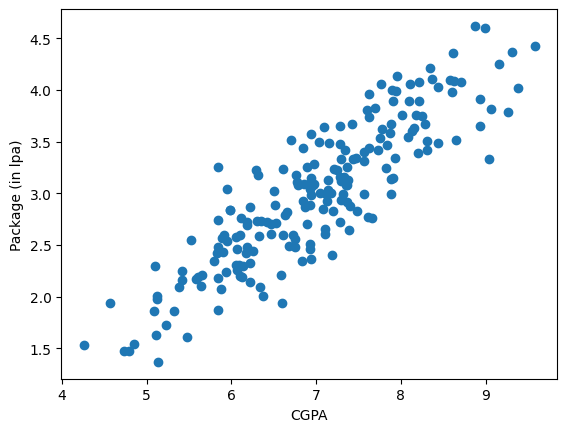

In [4]:
plt.scatter(df["cgpa"],df['package'])
plt.xlabel("CGPA")
plt.ylabel("Package (in lpa)")


In [5]:
X=df.iloc[:,0:1]
y=df.iloc[:,-1]

In [6]:
y

0      3.26
1      1.98
2      3.25
3      3.67
4      3.57
       ... 
195    2.46
196    2.57
197    3.24
198    3.96
199    2.33
Name: package, Length: 200, dtype: float64

In [12]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)


In [13]:
from sklearn.linear_model import LinearRegression

In [14]:
lr=LinearRegression()

In [15]:
lr.fit(X_train,y_train)

LinearRegression()

Text(0, 0.5, 'Package (in lpa)')

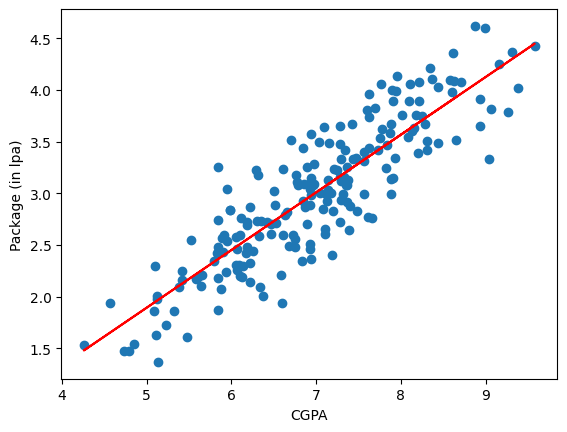

In [17]:
plt.scatter(df['cgpa'],df['package'])
plt.plot(X_train,lr.predict(X_train),color="red")
plt.xlabel('CGPA')
plt.ylabel('Package (in lpa)')

In [18]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score


In [21]:
y_pred=lr.predict(X_test)

In [20]:
y_test.values

array([4.1 , 3.49, 2.08, 2.33, 1.94, 1.48, 1.86, 3.09, 4.21, 2.87, 3.65,
       4.  , 2.89, 2.6 , 2.99, 3.25, 1.86, 3.67, 2.37, 3.42, 2.48, 3.65,
       2.6 , 2.83, 4.08, 2.56, 3.58, 3.81, 4.09, 2.01, 3.63, 2.92, 3.51,
       1.94, 2.21, 3.34, 3.34, 3.23, 2.01, 2.61])

In [22]:
print("The MAE:",mean_absolute_error(y_test,y_pred))

The MAE: 0.2884710931878175


In [24]:
print("The MSE:",mean_squared_error(y_test,y_pred))

The MSE: 0.12129235313495527


In [26]:
print("RMSE",np.sqrt(mean_squared_error(y_test,y_pred)))


RMSE 0.34827051717731616


In [30]:
print("THe R2",r2_score(y_test,y_pred))
r2=r2_score(y_test,y_pred)


THe R2 0.780730147510384


In [31]:
#Adjusted R2 score 
X_test.shape

(40, 1)

In [32]:
1-((1-r2)*(40-1)/(40-1-1))

0.7749598882343415

In [33]:
new_df1=df.copy()
new_df1['random_features'] =np.random.random(200)

new_df1=new_df1[['cgpa','random_features','package']]
new_df1.head()

,cgpa,random_features,package
0,6.89,0.713236,3.26
1,5.12,0.111399,1.98
2,7.82,0.989405,3.25
3,7.42,0.096398,3.67
4,6.94,0.641368,3.57


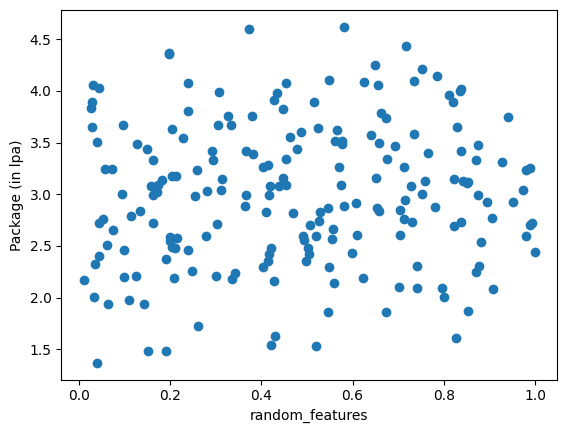

In [35]:
plt.scatter(new_df1['random_features'],new_df1['package'])
plt.xlabel('random_features')
plt.ylabel('Package (in lpa)')
plt.show()

In [37]:
X=new_df1.iloc[:,0:2]
y=new_df1.iloc[:,-1]

In [38]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=2)


In [39]:
lr=LinearRegression()

In [40]:
lr.fit(X_train,y_train)

LinearRegression()

In [41]:
y_pred=lr.predict(X_test)

In [42]:
print("R2 scored :",r2_score(y_test,y_pred))

R2 scored : 0.7795698198094376


In [43]:
1 - ((1-r2)*(40-1)/(40-1-2))

0.7688777230514858

now make a new data set of the colums effect output 

In [44]:
new_df2=df.copy()
new_df2['iq'] =new_df2['package']+(np.random.randint(-12,12,200)/10)

new_df2=new_df2[['cgpa','iq','package']]

In [45]:
new_df2.sample(5)

,cgpa,iq,package
102,5.13,0.27,1.37
199,6.22,3.43,2.33
36,5.99,3.74,2.84
47,5.84,2.26,3.26
137,7.14,2.33,3.13


Text(0, 0.5, 'PAckage in lpa ')

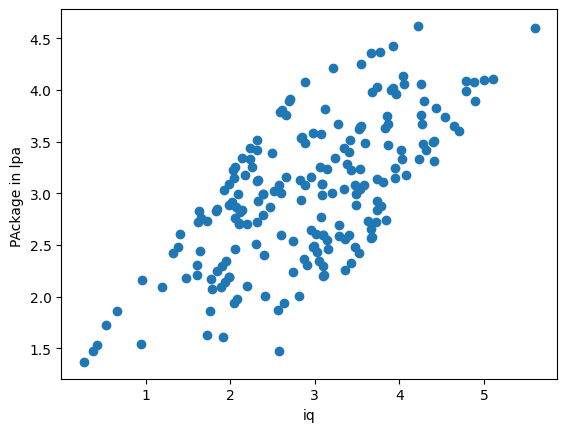

In [46]:
plt.scatter(new_df2['iq'],new_df2['package'])
plt.xlabel('iq')
plt.ylabel("PAckage in lpa ")

In [47]:
np.random.randint(-100,100)

76

In [48]:
X=new_df2.iloc[:,0:2]
y=new_df2.iloc[:,-1]

In [49]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=2)


In [50]:
lr=LinearRegression()
lr.fit(X_train,y_train)
y_pred=lr.predict(X_test)

In [51]:
print("R2 score:",r2_score(y_test,y_pred))
r2=r2_score(y_test,y_pred)

R2 score: 0.8209173052481533


In [52]:
1 - ((1-r2)*(40-1)/(40-1-2))

0.8112371595858914